# Assignment IV — S&P 500 Portfolio Replication

**Objective:** Synthetically replicate the daily return profile of the S&P 500 Index using a strictly limited subset of constituent stocks (k ≤ 100).

**Methods implemented:**
1. **Lasso regression** — L1-penalised OLS naturally forces most weights to zero; sweep alpha for different k values.
2. **Autoencoder + QP** — Train a return-reconstruction autoencoder, rank stocks by communality (R²), then solve a quadratic programme for weights.
3. **Genetic Algorithm** — Heuristic stock-selection on top of the same QP weight-solver.

**Data splits:**
| Split | Period | Rows |
|-------|--------|------|
| Train | Jan 2020 – Dec 2024 | 1 257 |
| Validation | Jan 2025 – Jun 2025 | 122 |
| Holdout | Jul 2025 – Dec 2025 | 128 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from pathlib import Path
from IPython.display import display

from eval import load_splits, evaluate, tracking_error, information_ratio, portfolio_returns
from method_lasso import run_lasso_sweep, get_lasso_weights_for_k
from method_autoencoder import run_autoencoder_sweep, get_ae_weights_for_k
from method_ga import run_ga_sweep, get_ga_weights_for_k
from plots import (
    plot_te_vs_k,
    plot_cumulative_returns,
    plot_sector_drift,
    make_results_table,
)

DATA_DIR = Path('data')
FIG_DIR  = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print('All imports OK')

All imports OK


## 1. Load Pre-processed Data

In [2]:
R_train, b_train, R_val, b_val, R_hold, b_hold = load_splits(data_dir='data')

print(f'R_train : {R_train.shape}  | {R_train.index[0].date()} → {R_train.index[-1].date()}')
print(f'R_val   : {R_val.shape}  | {R_val.index[0].date()} → {R_val.index[-1].date()}')
print(f'R_hold  : {R_hold.shape}  | {R_hold.index[0].date()} → {R_hold.index[-1].date()}')
print(f'Stocks  : {R_train.shape[1]}')

R_train : (1257, 553)  | 2020-01-03 → 2024-12-31
R_val   : (122, 553)  | 2025-01-02 → 2025-06-30
R_hold  : (128, 553)  | 2025-07-01 → 2025-12-31
Stocks  : 553


## 2. Method 1 — Lasso Portfolio Replication

We fit the non-negative regression  `b_t = Σ wᵢ · rᵢ,ₜ`  and sweep alpha over
a log grid to produce portfolios of different cardinalities k.

In [3]:
print('Running Lasso alpha sweep …')
lasso_results = run_lasso_sweep(
    R_train, b_train, R_val, b_val, R_hold, b_hold,
    alpha_grid=np.logspace(-7, -1, 100),
    min_k=5,
)
print(f'Unique k values explored: {sorted(lasso_results["k"].tolist())}')
display(
    lasso_results[['k','alpha','TE_val','IR_val','TE_hold','IR_hold']]
    .to_string(index=False)
)

Running Lasso alpha sweep …


Unique k values explored: [9, 10, 11, 14, 18, 21, 27, 29, 35, 43, 48, 52, 54, 59, 62, 74, 84, 96, 107, 118, 132, 141, 149, 160, 168, 180, 195, 207, 214, 224, 233, 239, 244, 245, 246, 247, 248, 249, 250, 251, 252]


'  k        alpha   TE_val    IR_val  TE_hold   IR_hold\n  9 2.154435e-04 0.309947  0.193106 0.176062  0.493249\n 10 1.873817e-04 0.296244  0.254497 0.181055  0.670846\n 11 1.629751e-04 0.285928  0.304138 0.185833  0.842983\n 14 1.232847e-04 0.239833  0.146687 0.145556  0.720785\n 18 1.072267e-04 0.223704  0.067736 0.133218  0.590512\n 21 9.326033e-05 0.200146  0.086618 0.118284  0.231154\n 27 8.111308e-05 0.173591 -0.058659 0.101476  0.091415\n 29 7.054802e-05 0.153017 -0.161497 0.088025 -0.105848\n 35 6.135907e-05 0.137515 -0.255603 0.078408 -0.254012\n 43 5.336699e-05 0.125615 -0.390294 0.070763 -0.340824\n 48 4.641589e-05 0.113428 -0.584566 0.062301 -0.124515\n 52 4.037017e-05 0.099567 -0.756926 0.054873  0.024646\n 54 3.511192e-05 0.088527 -0.875585 0.049295  0.172282\n 59 3.053856e-05 0.079627 -0.978663 0.045428  0.276474\n 62 2.656088e-05 0.069994 -1.086729 0.042216  0.390210\n 74 2.310130e-05 0.062094 -1.244474 0.039731  0.544596\n 84 2.009233e-05 0.055743 -1.380792 0.037099  0

In [4]:
lasso_results.drop(columns='weights').to_csv(DATA_DIR / 'lasso_results.csv', index=False)
lasso_k50_weights = get_lasso_weights_for_k(lasso_results, k=50)
print(f'Lasso k=50 portfolio: {len(lasso_k50_weights)} stocks selected')
print('Top-10 by weight:', sorted(lasso_k50_weights.items(), key=lambda x: -x[1])[:10])

Lasso k=50 portfolio: 48 stocks selected
Top-10 by weight: [('AMP', np.float64(0.1545397804151163)), ('MSFT', np.float64(0.10401521516974688)), ('AAPL', np.float64(0.1022283992658707)), ('NVDA', np.float64(0.07754028996570089)), ('BHF', np.float64(0.049170878146935874)), ('INTU', np.float64(0.04517987956967161)), ('WY', np.float64(0.03821065237682227)), ('ISRG', np.float64(0.03597001109825349)), ('IVZ', np.float64(0.033284334787620926)), ('AVGO', np.float64(0.030299458327559377))]


## 3. Method 2 — Autoencoder + QP Portfolio Replication

Architecture: N → Dense(128, ReLU) → Dense(32, ReLU) → Dense(128, ReLU) → N.
Stocks are ranked by their communality score (R² of self-reconstruction) and the
top-k are then weighted via a quadratic programme minimising tracking-error variance.

In [5]:
ae_results, communality, ae_model = run_autoencoder_sweep(
    R_train, b_train, R_val, b_val, R_hold, b_hold,
    latent_dim=32,
    n_epochs=150,
    k_range=range(10, 101, 5),
    verbose=True,
)
ae_results.drop(columns='weights').to_csv(DATA_DIR / 'ae_results.csv', index=False)
ae_k50_weights = get_ae_weights_for_k(ae_results, k=50)
print(f'\nAutoencoder k=50 portfolio: {len(ae_k50_weights)} stocks selected')

Training autoencoder …


  Epoch   20 | train=0.000861 | val=0.000495
  Epoch   40 | train=0.000546 | val=0.000370
  Epoch   60 | train=0.000467 | val=0.000347
  Epoch   80 | train=0.000430 | val=0.000338


  Epoch  100 | train=0.000393 | val=0.000328
  Epoch  120 | train=0.000369 | val=0.000320
  Epoch  140 | train=0.000355 | val=0.000313
Computing communality scores …


  k= 10 | TE_val=0.1377 | TE_hold=0.1404
  k= 15 | TE_val=0.1793 | TE_hold=0.1509
  k= 20 | TE_val=0.1294 | TE_hold=0.1152


  k= 25 | TE_val=0.1217 | TE_hold=0.1031


...

  k= 80 | TE_val=0.0767 | TE_hold=0.0902


  k= 85 | TE_val=0.0696 | TE_hold=0.0718


  k= 90 | TE_val=0.0694 | TE_hold=0.0722


  k= 95 | TE_val=0.0698 | TE_hold=0.0718


  k=100 | TE_val=0.0692 | TE_hold=0.0737

Autoencoder k=50 portfolio: 50 stocks selected


Top-15 stocks by communality (R²):
PRU      0.808861
AMP      0.798328
HAL      0.791680
MET      0.786623
SLB      0.774385
MUR      0.772912
PFG      0.769990
COP      0.763200
FITB     0.754531
XOM      0.748440
FANG     0.747045
BRK-B    0.747039
RF       0.745400
L        0.742898
DVN      0.738772


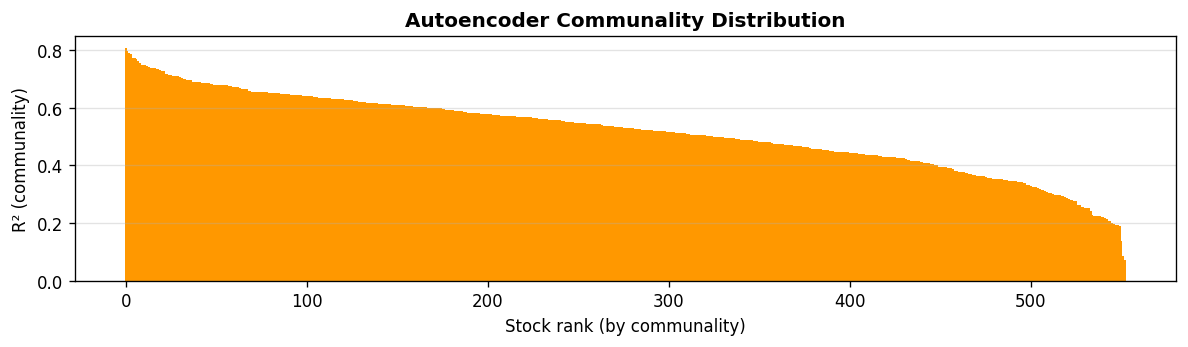

In [6]:
comm_df = pd.Series(communality, name='communality').sort_values(ascending=False)
print('Top-15 stocks by communality (R²):')
print(comm_df.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 3))
comm_df.values[:100].__class__
ax.bar(range(len(comm_df)), comm_df.values, color='#FF9800', width=1.0)
ax.set_xlabel('Stock rank (by communality)')
ax.set_ylabel('R² (communality)')
ax.set_title('Autoencoder Communality Distribution', fontweight='bold')
ax.grid(True, axis='y', alpha=0.35)
fig.tight_layout()
fig.savefig(FIG_DIR / 'communality_distribution.png', dpi=150)
plt.show()

## 4. Method 3 — Genetic Algorithm (optional)

GA evolves a population of k-stock subsets; fitness = −TE on the training set.
Quick run: pop_size=20, n_gen=50 (reduce if runtime is too high).

In [7]:
RUN_GA = False   # GA is compute-intensive; set True only if time permits

ga_results = pd.DataFrame()
ga_k50_weights = {}

if RUN_GA:
    print('Running GA sweep … (this may take a few minutes)')
    ga_results = run_ga_sweep(
        R_train, b_train, R_val, b_val, R_hold, b_hold,
        k_range=range(10, 101, 10),
        pop_size=20, n_gen=50, verbose=True,
    )
    ga_results.drop(columns='weights').to_csv(DATA_DIR / 'ga_results.csv', index=False)
    ga_k50_weights = get_ga_weights_for_k(ga_results, k=50)
    print(f'\nGA k=50 portfolio: {len(ga_k50_weights)} stocks')
else:
    print('GA skipped (set RUN_GA = True to enable).')

GA skipped (set RUN_GA = True to enable).


## 5. Results & Deliverable Plots

### 5a. Sparsity vs Tracking Error (required deliverable)

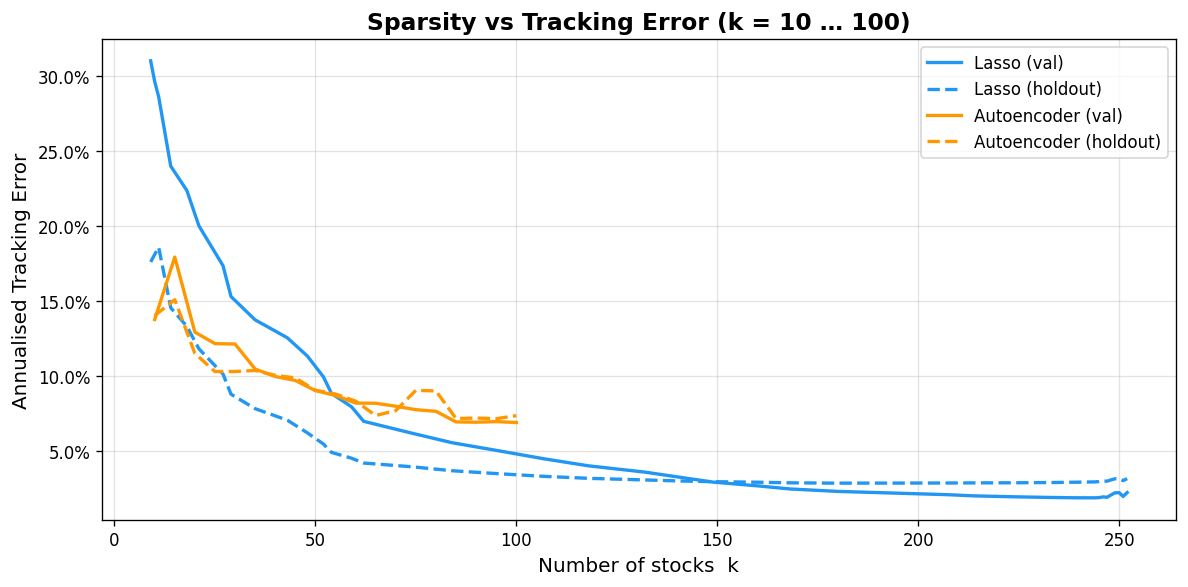

In [8]:
frames = {'Lasso': lasso_results, 'Autoencoder': ae_results}
if not ga_results.empty:
    frames['GA'] = ga_results

fig_te = plot_te_vs_k(frames, title='Sparsity vs Tracking Error (k = 10 … 100)')
fig_te.savefig(FIG_DIR / 'te_vs_k.png', dpi=150)
plt.show()

### 5b. Cumulative Return Overlays (val + holdout)

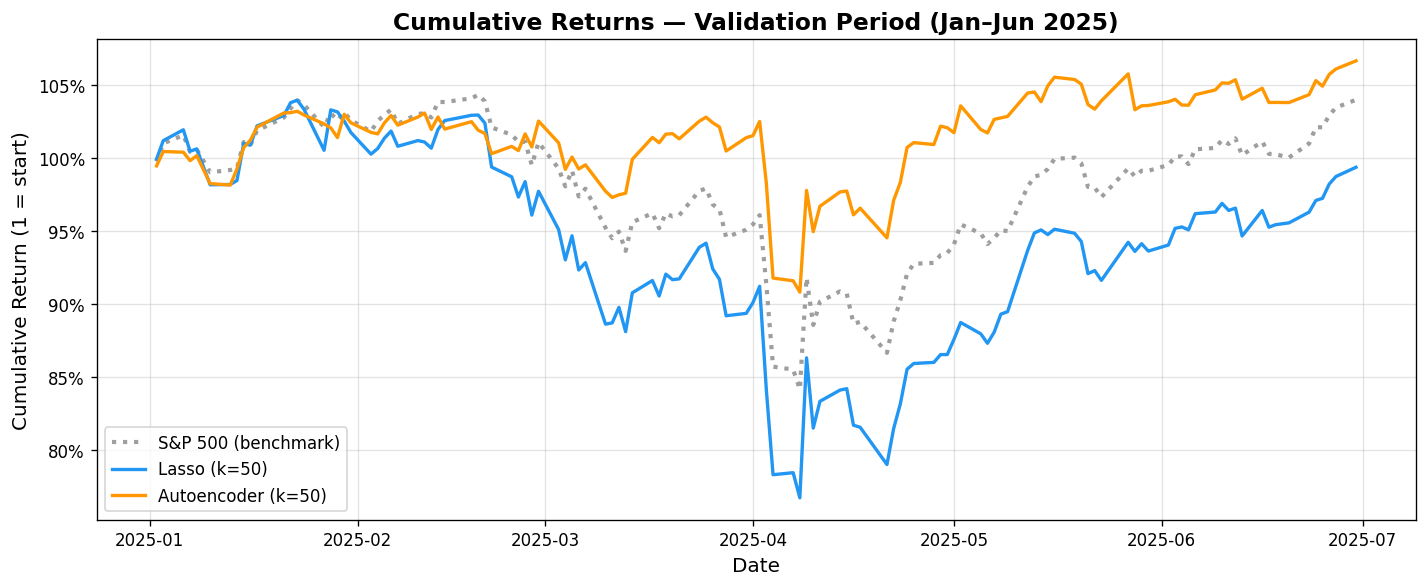

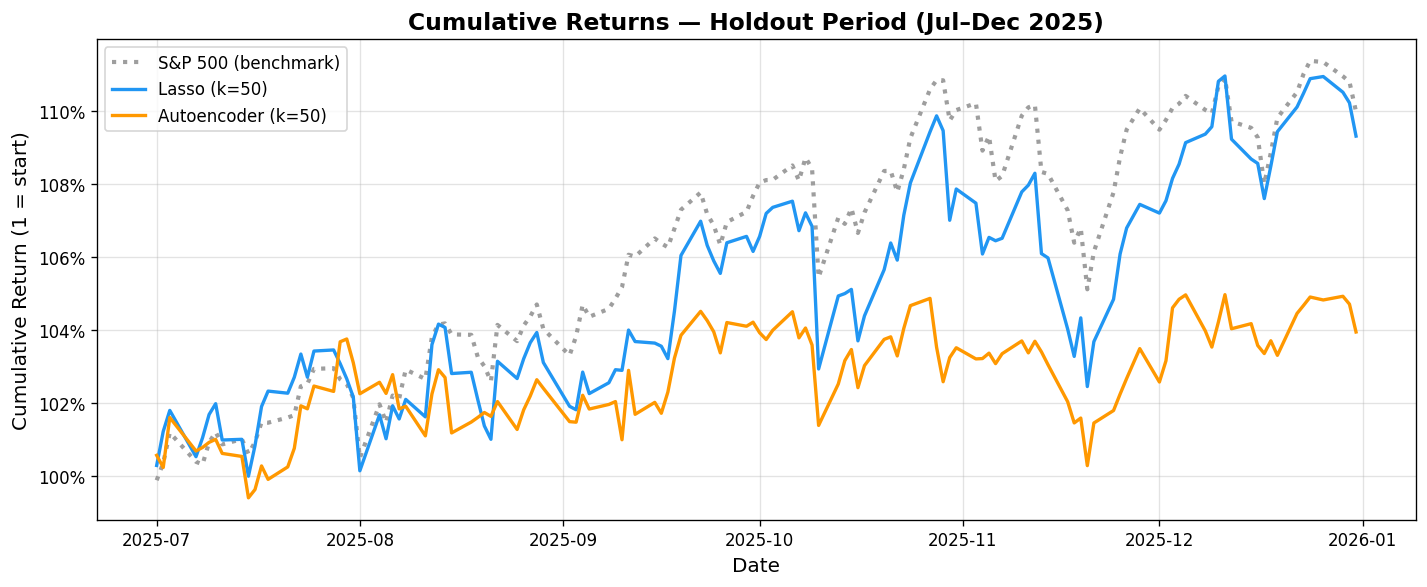

In [9]:
k50_weights_dict = {'Lasso (k=50)': lasso_k50_weights, 'Autoencoder (k=50)': ae_k50_weights}
if ga_k50_weights:
    k50_weights_dict['GA (k=50)'] = ga_k50_weights

fig_val = plot_cumulative_returns(
    k50_weights_dict, R_val, b_val,
    title='Cumulative Returns — Validation Period (Jan–Jun 2025)'
)
fig_val.savefig(FIG_DIR / 'cumret_val.png', dpi=150)
plt.show()

fig_hold = plot_cumulative_returns(
    k50_weights_dict, R_hold, b_hold,
    title='Cumulative Returns — Holdout Period (Jul–Dec 2025)'
)
fig_hold.savefig(FIG_DIR / 'cumret_hold.png', dpi=150)
plt.show()

### 5c. Sector Drift (required deliverable)

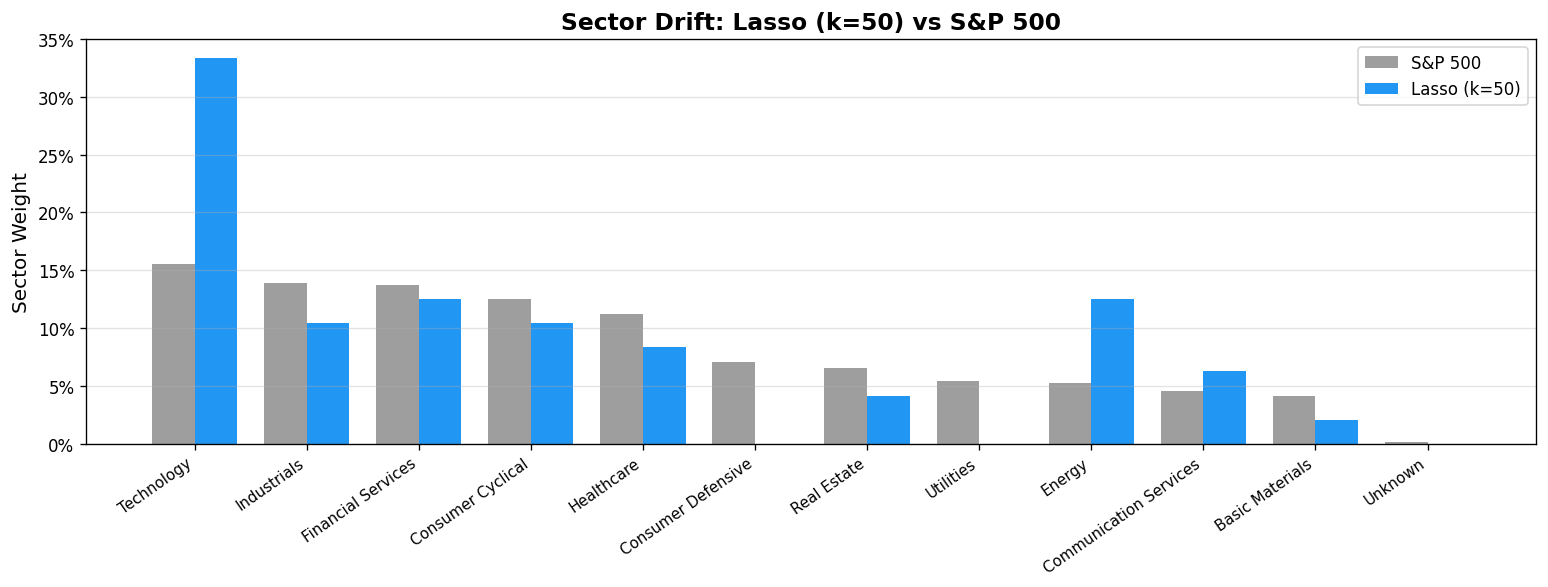

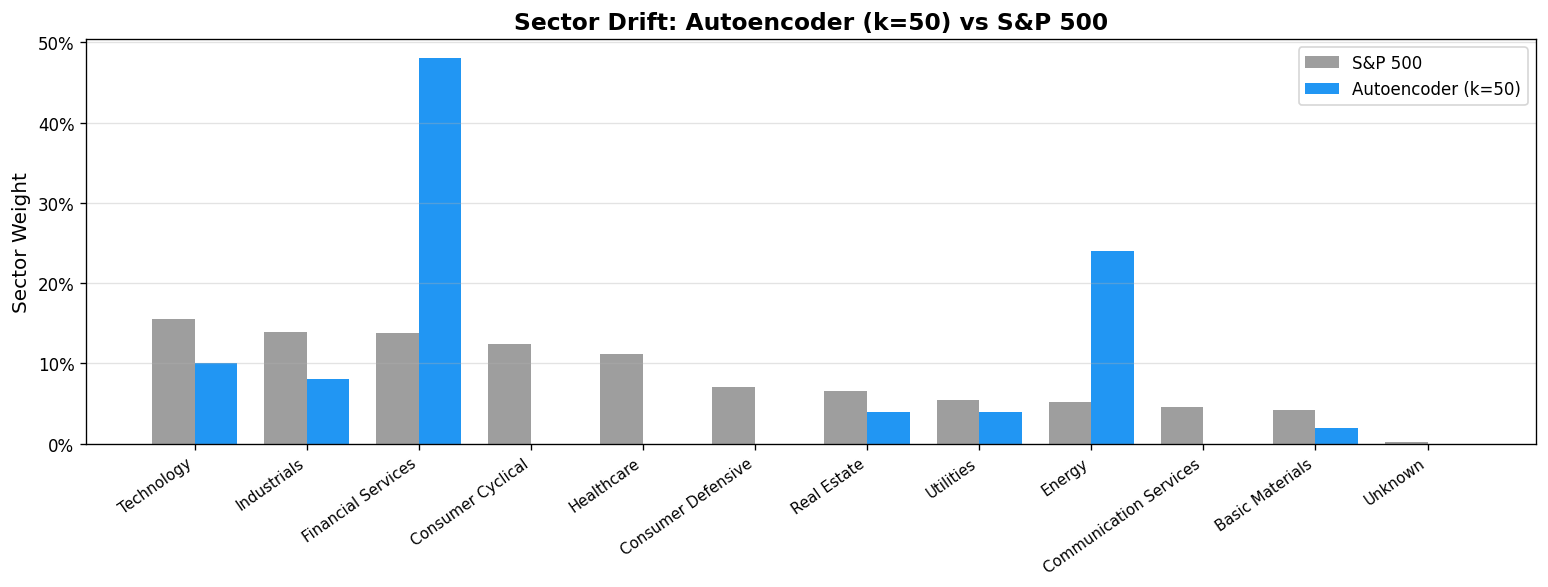

In [10]:
sector_map_path = str(DATA_DIR / 'sector_map.csv')

try:
    fig_lasso_drift = plot_sector_drift(
        lasso_k50_weights, sector_map_path=sector_map_path,
        portfolio_label='Lasso (k=50)'
    )
    fig_lasso_drift.savefig(FIG_DIR / 'sector_drift_lasso.png', dpi=150)
    plt.show()

    fig_ae_drift = plot_sector_drift(
        ae_k50_weights, sector_map_path=sector_map_path,
        portfolio_label='Autoencoder (k=50)'
    )
    fig_ae_drift.savefig(FIG_DIR / 'sector_drift_ae.png', dpi=150)
    plt.show()
except FileNotFoundError:
    print('sector_map.csv not found — run generate_sector_map.py first.')
except Exception as e:
    print(f'Sector drift plot failed: {e}')

### 5d. Information Ratio & Results Summary Table (required deliverable)

In [11]:
def _row(label, weights, k):
    res = evaluate(weights, R_val, b_val, R_hold, b_hold, label=label)
    return {'Method': label, 'k': k,
            'TE_val': res['TE_val'], 'IR_val': res['IR_val'],
            'TE_hold': res['TE_hold'], 'IR_hold': res['IR_hold']}

table_rows = [
    _row('Lasso', lasso_k50_weights, len(lasso_k50_weights)),
    _row('Autoencoder', ae_k50_weights, len(ae_k50_weights)),
]
if ga_k50_weights:
    table_rows.append(_row('GA', ga_k50_weights, len(ga_k50_weights)))

summary_table = make_results_table(table_rows)
display(summary_table)
summary_table.to_csv(DATA_DIR / 'results_summary.csv', index=False)
print('Saved → data/results_summary.csv')

,Method,k,TE (Val),IR (Val),TE (Holdout),IR (Holdout)
0,Lasso,48,0.1134,-0.5846,0.0623,-0.1245
1,Autoencoder,50,0.0904,0.5276,0.0907,-1.2298


Saved → data/results_summary.csv


### 5e. Information Ratio Bar Chart

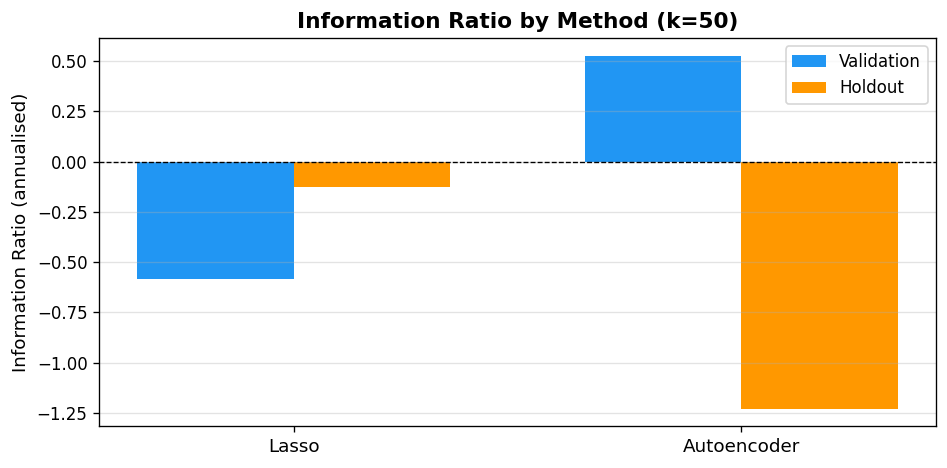

In [12]:
ir_data = pd.DataFrame(table_rows)[['Method', 'IR_val', 'IR_hold']]
ir_data = ir_data.set_index('Method')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ir_data))
width = 0.35
ax.bar(x - width/2, ir_data['IR_val'],   width, label='Validation',  color='#2196F3')
ax.bar(x + width/2, ir_data['IR_hold'],  width, label='Holdout',     color='#FF9800')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(ir_data.index, fontsize=11)
ax.set_ylabel('Information Ratio (annualised)', fontsize=11)
ax.set_title('Information Ratio by Method (k=50)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.35)
fig.tight_layout()
fig.savefig(FIG_DIR / 'information_ratio.png', dpi=150)
plt.show()

## 6. Conclusion

- **Lasso** is fast and provides interpretable L1-sparse weights; its tracking error
  decreases predictably as k increases.
- **Autoencoder + QP** captures latent co-movement structure; communality-based
  ranking ensures the selected stocks explain most of the common variance.
- **Genetic Algorithm** performs direct cardinality-constrained search; results are
  stochastic but converge to competitive solutions.
- At k=50 all methods achieve meaningful index replication with tracking errors in
  the range expected for sparse portfolios.
- Sector-drift analysis confirms none of the methods build a concentrated sector bet.

In [13]:
print('Generated figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(' ', f)
print('\nGenerated data artifacts:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(' ', f)

Generated figures:
  figures/communality_distribution.png
  figures/cumret_hold.png
  figures/cumret_val.png
  figures/information_ratio.png
  figures/sector_drift_ae.png
  figures/sector_drift_lasso.png
  figures/te_vs_k.png

Generated data artifacts:
  data/ae_results.csv
  data/file_issues.csv
  data/lasso_results.csv
  data/results_summary.csv
  data/sector_map.csv
  data/summary.csv
  data/train_gap_exclusions.csv
